# 0.8 Mechanism A: EIP-8037 + Separated Bandwidth

This notebook replays **Mechanism A** on the 500-block sample:

```text
execution_state_used = max(execution_gas_used, state_gas_8037)
bandwidth_bytes = calldata + BAL + tx access-list + authorization-list + blob-hash bytes
bandwidth_gas = 16 * bandwidth_bytes
```

Important: this still uses the EIP-8037 state baseline. State does **not** have
its own EIP-7999 target, limit, excess accumulator, or base fee here. The only
new separated EIP-7999-style resource in this notebook is bandwidth.

There is no EIP-7976 `64 gas/byte` calldata floor and no EIP-7981 `64 gas/byte`
access-list surcharge in this mechanism. Those are Glamsterdam in-gas-accounting
rules. Mechanism A instead separates data into its own bandwidth dimension.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from mechanisms import (
    PassiveBlockUsage,
    make_mechanism_A_config,
    replay_bandwidth_7999_state_8037,
)

pd.options.display.float_format = "{:,.4f}".format


## Parameters

The execution/state side uses the EIP-8037-style 30M target and 60M limit.
Bandwidth is the new separated resource; for this first pass we use a 60M limit
and 15M target.

For this notebook, every metered bandwidth byte is mapped to `16` bandwidth gas:
calldata, BAL RLP, transaction access-list bytes, authorization tuple bytes, and
blob versioned hash bytes.

In [2]:
START_BLOCK = 24_120_001
END_BLOCK = 24_120_500

EXECUTION_STATE_GAS_LIMIT = 60_000_000
EXECUTION_STATE_GAS_TARGET = 30_000_000

BANDWIDTH_GAS_PER_BYTE = 16
BANDWIDTH_GAS_LIMIT = 60_000_000
BANDWIDTH_GAS_TARGET = 15_000_000
BANDWIDTH_TARGET_RATIO = BANDWIDTH_GAS_LIMIT // BANDWIDTH_GAS_TARGET
BANDWIDTH_RESERVE_FACTOR = 12

INITIAL_BANDWIDTH_BASE_FEE = None  # None means use the first historical base fee

DATA_DIR = PROJECT_ROOT / "data"
PLOTS_DIR = PROJECT_ROOT / "plots"
PLOTS_DIR.mkdir(exist_ok=True)

TX_REPRICE_CSV = DATA_DIR / f"glamsterdam_tx_regular_gas_repriced_{START_BLOCK}_{END_BLOCK}.csv"
REGULAR_RECALC_CSV = DATA_DIR / f"glamsterdam_regular_gas_recalculation_{START_BLOCK}_{END_BLOCK}.csv"
BANDWIDTH_CSV = DATA_DIR / f"bandwidth_content_8131_{START_BLOCK}_{END_BLOCK}.csv"
BLOB_BASE_FEE_CSV = DATA_DIR / f"rpc_blob_base_fee_{START_BLOCK}_{END_BLOCK}.csv"

OUT_REPLAY_CSV = DATA_DIR / f"mechanism_A_8037_plus_bandwidth_replay_{START_BLOCK}_{END_BLOCK}.csv"
OUT_SUMMARY_CSV = DATA_DIR / f"mechanism_A_8037_plus_bandwidth_summary_{START_BLOCK}_{END_BLOCK}.csv"

OUT_RESOURCE_GAS_PLOT = PLOTS_DIR / f"mechanism_A_resource_gas_{START_BLOCK}_{END_BLOCK}.png"
OUT_BANDWIDTH_COMPONENTS_PLOT = PLOTS_DIR / f"mechanism_A_bandwidth_components_{START_BLOCK}_{END_BLOCK}.png"
OUT_BASE_FEE_PLOT = PLOTS_DIR / f"mechanism_A_base_fees_{START_BLOCK}_{END_BLOCK}.png"
OUT_EXCESS_PLOT = PLOTS_DIR / f"mechanism_A_bandwidth_excess_{START_BLOCK}_{END_BLOCK}.png"

for path in [TX_REPRICE_CSV, REGULAR_RECALC_CSV, BANDWIDTH_CSV, BLOB_BASE_FEE_CSV]:
    if not path.exists():
        raise FileNotFoundError(path)

START_BLOCK, END_BLOCK, EXECUTION_STATE_GAS_TARGET, EXECUTION_STATE_GAS_LIMIT, BANDWIDTH_GAS_TARGET, BANDWIDTH_GAS_LIMIT, BANDWIDTH_RESERVE_FACTOR


(24120001, 24120500, 30000000, 60000000, 15000000, 60000000, 12)

## Build Passive Inputs

`state_gas_8037` comes from the RPC-calibrated EIP-8037 state-growth estimator.

For execution gas, we start from historical receipt gas and remove only the gas
components that are moved out of the execution/state dimension:

```text
execution_gas_used = historical gas used
  - historical state-creation gas moved into EIP-8037 state gas
  - current calldata charge moved into bandwidth
```

The current calldata charge is computed at transaction level:

```text
ordinary tx:      4/16 standard calldata gas
EIP-7623-bound tx: 10/40 calldata floor charge
```

Equivalently, this subtracts standard calldata gas plus any observed EIP-7623
floor uplift. It does **not** apply the EIP-7976 `64 gas/byte` floor or the
EIP-7981 access-list data surcharge, because those are not part of this
separated-bandwidth mechanism.

Access-list bytes, authorization tuples, blob hashes, and BALs are not
subtracted from historical execution gas here; they become new counterfactual
bandwidth-resource terms.

In [3]:
tx = pd.read_csv(TX_REPRICE_CSV)
regular = pd.read_csv(REGULAR_RECALC_CSV)
bandwidth = pd.read_csv(BANDWIDTH_CSV)
blob_fee = pd.read_csv(BLOB_BASE_FEE_CSV)[["block_number", "blob_base_fee_per_gas"]]

# Current calldata de-accounting: standard 4/16 calldata gas plus observed
# EIP-7623 10/40 floor uplift for calldata-heavy transactions.
tx["current_calldata_deaccounted_gas"] = tx["standard_calldata_gas"].astype("int64")
floor_mask = tx["current_floor_binds_observed"].astype(bool)
tx.loc[floor_mask, "current_calldata_deaccounted_gas"] = tx.loc[
    floor_mask,
    "current_7623_floor_gas",
].astype("int64")
tx["current_7623_floor_uplift_observed"] = (
    tx["current_calldata_deaccounted_gas"]
    - tx["standard_calldata_gas"].astype("int64")
)

tx_agg = (
    tx.groupby("block_number", as_index=False)
    .agg(
        tx_count=("tx_hash", "count"),
        current_gas_used_from_txs=("receipt_gas_used", "sum"),
        standard_calldata_gas_current=("standard_calldata_gas", "sum"),
        current_calldata_deaccounted_gas=("current_calldata_deaccounted_gas", "sum"),
        current_7623_floor_uplift_observed=("current_7623_floor_uplift_observed", "sum"),
        current_7623_floor_bound_txs=("current_floor_binds_observed", "sum"),
        historical_state_creation_gas_tx=("historical_state_creation_gas", "sum"),
        calldata_bytes_from_txs=("calldata_bytes", "sum"),
    )
)

inputs = (
    regular[
        [
            "block_number",
            "timestamp",
            "gas_used",
            "gas_limit",
            "base_fee_per_gas",
            "gas_state_growth",
            "historical_state_creation_gas_total",
            "state_gas_8037",
            "state_gas_source",
        ]
    ]
    .merge(tx_agg, on="block_number", how="inner", validate="one_to_one")
    .merge(bandwidth, on="block_number", how="inner", validate="one_to_one")
    .merge(blob_fee, on="block_number", how="inner", validate="one_to_one")
    .sort_values("block_number")
    .reset_index(drop=True)
)

if not (inputs["gas_used"].astype("int64") == inputs["current_gas_used_from_txs"].astype("int64")).all():
    bad = inputs.loc[
        inputs["gas_used"].astype("int64") != inputs["current_gas_used_from_txs"].astype("int64"),
        ["block_number", "gas_used", "current_gas_used_from_txs"],
    ]
    raise ValueError("Transaction gas does not sum to block gas:\n" + bad.head().to_string(index=False))

if not (inputs["calldata_bytes"].astype("int64") == inputs["calldata_bytes_from_txs"].astype("int64")).all():
    bad = inputs.loc[
        inputs["calldata_bytes"].astype("int64") != inputs["calldata_bytes_from_txs"].astype("int64"),
        ["block_number", "calldata_bytes", "calldata_bytes_from_txs"],
    ]
    raise ValueError("Transaction calldata does not match bandwidth table:\n" + bad.head().to_string(index=False))

inputs["current_gas_used"] = inputs["gas_used"].astype("int64")
inputs["historical_state_creation_gas"] = inputs["historical_state_creation_gas_total"].astype("int64")
inputs["execution_gas_used"] = (
    inputs["current_gas_used"]
    - inputs["historical_state_creation_gas"]
    - inputs["current_calldata_deaccounted_gas"].astype("int64")
)
inputs["state_gas_8037"] = inputs["state_gas_8037"].astype("int64")
inputs["execution_state_gas_used"] = inputs[["execution_gas_used", "state_gas_8037"]].max(axis=1)

if (inputs["execution_gas_used"] < 0).any():
    bad = inputs.loc[inputs["execution_gas_used"] < 0, ["block_number", "execution_gas_used"]]
    raise ValueError("Negative execution gas after de-accounting:\n" + bad.head().to_string(index=False))

# Mechanism A bandwidth metering: all metered bytes use 16 bandwidth gas/byte.
inputs["bandwidth_calldata_gas"] = inputs["calldata_bytes"].astype("int64") * BANDWIDTH_GAS_PER_BYTE
inputs["bandwidth_bal_gas"] = inputs["bal_rlp_bytes"].astype("int64") * BANDWIDTH_GAS_PER_BYTE
inputs["bandwidth_tx_access_list_gas"] = inputs["tx_access_list_bytes"].astype("int64") * BANDWIDTH_GAS_PER_BYTE
inputs["bandwidth_authorization_tuple_gas"] = inputs["authorization_tuple_8131_bytes"].astype("int64") * BANDWIDTH_GAS_PER_BYTE
inputs["bandwidth_blob_versioned_hash_gas"] = inputs["blob_versioned_hash_bytes"].astype("int64") * BANDWIDTH_GAS_PER_BYTE
inputs["bandwidth_gas_used"] = (
    inputs["bandwidth_calldata_gas"]
    + inputs["bandwidth_bal_gas"]
    + inputs["bandwidth_tx_access_list_gas"]
    + inputs["bandwidth_authorization_tuple_gas"]
    + inputs["bandwidth_blob_versioned_hash_gas"]
)
inputs["bandwidth_bytes"] = inputs["bandwidth_metered_bytes"].astype("int64")
inputs["blob_base_fee_per_gas"] = inputs["blob_base_fee_per_gas"].astype("int64")
inputs["bandwidth_reserve_anchor_base_fee"] = (
    inputs["blob_base_fee_per_gas"] + BANDWIDTH_RESERVE_FACTOR - 1
) // BANDWIDTH_RESERVE_FACTOR

if not (inputs["bandwidth_gas_used"] == inputs["bandwidth_bytes"] * BANDWIDTH_GAS_PER_BYTE).all():
    raise AssertionError("bandwidth gas must equal 16 * metered bandwidth bytes")

inputs["execution_state_limit_exceeded"] = inputs["execution_state_gas_used"] > EXECUTION_STATE_GAS_LIMIT
inputs["bandwidth_limit_exceeded"] = inputs["bandwidth_gas_used"] > BANDWIDTH_GAS_LIMIT
inputs["any_limit_exceeded"] = inputs["execution_state_limit_exceeded"] | inputs["bandwidth_limit_exceeded"]
inputs["execution_state_usage_pct_target"] = inputs["execution_state_gas_used"] / EXECUTION_STATE_GAS_TARGET
inputs["execution_state_usage_pct_limit"] = inputs["execution_state_gas_used"] / EXECUTION_STATE_GAS_LIMIT
inputs["bandwidth_usage_pct_target"] = inputs["bandwidth_gas_used"] / BANDWIDTH_GAS_TARGET
inputs["bandwidth_usage_pct_limit"] = inputs["bandwidth_gas_used"] / BANDWIDTH_GAS_LIMIT

inputs[
    [
        "block_number",
        "current_gas_used",
        "historical_state_creation_gas",
        "standard_calldata_gas_current",
        "current_7623_floor_uplift_observed",
        "current_calldata_deaccounted_gas",
        "execution_gas_used",
        "state_gas_8037",
        "execution_state_gas_used",
        "bandwidth_bytes",
        "bandwidth_gas_used",
        "blob_base_fee_per_gas",
        "bandwidth_reserve_anchor_base_fee",
    ]
].head()

,block_number,current_gas_used,historical_state_creation_gas,standard_calldata_gas_current,current_7623_floor_uplift_observed,current_calldata_deaccounted_gas,execution_gas_used,state_gas_8037,execution_state_gas_used,bandwidth_bytes,bandwidth_gas_used,blob_base_fee_per_gas,bandwidth_reserve_anchor_base_fee
0,24120001,59964904,7384500,2082460,2304,2084764,50495640,42310620,50495640,585660,9370560,3336041,278004
1,24120002,13753679,2420000,353648,0,353648,10980031,13693500,13693500,117317,1877072,3570969,297581
2,24120003,41015898,7778400,1148548,19062,1167610,32069888,43098570,43098570,324727,5195632,3684909,307076
3,24120004,23756933,5440400,598664,1536,600200,17716333,31432320,31432320,192563,3081008,3762881,313574
4,24120005,16941785,2364900,389416,768,390184,14186701,13558860,14186701,131428,2102848,3944405,328701


## Replay Mechanism A

The replay has exactly two fee resources:

- `execution_state`: EIP-8037 max bottleneck with EIP-1559 linear base-fee update.
- `bandwidth`: separated EIP-7999-style resource with normalized excess and fake-exponential base-fee update.

State growth remains inside the shared EIP-8037 bottleneck. It is not a third
fee resource in this notebook.

In [4]:
initial_common_base_fee = int(inputs["base_fee_per_gas"].iloc[0])
initial_execution_state_base_fee = initial_common_base_fee
initial_bandwidth_base_fee = (
    initial_common_base_fee
    if INITIAL_BANDWIDTH_BASE_FEE is None
    else int(INITIAL_BANDWIDTH_BASE_FEE)
)

config = make_mechanism_A_config(
    execution_state_gas_limit=EXECUTION_STATE_GAS_LIMIT,
    bandwidth_gas_limit=BANDWIDTH_GAS_LIMIT,
    execution_state_target_ratio=EXECUTION_STATE_GAS_LIMIT // EXECUTION_STATE_GAS_TARGET,
    bandwidth_target_ratio=BANDWIDTH_TARGET_RATIO,
    initial_execution_state_base_fee=initial_execution_state_base_fee,
    initial_bandwidth_base_fee=initial_bandwidth_base_fee,
    bandwidth_reserve_factor=BANDWIDTH_RESERVE_FACTOR,
)

blocks = [
    PassiveBlockUsage(
        block_number=int(row.block_number),
        timestamp=None,
        execution_gas_used=int(row.execution_gas_used),
        state_gas_used=int(row.state_gas_8037),
        bandwidth_gas=int(row.bandwidth_gas_used),
        bandwidth_bytes=int(row.bandwidth_bytes),
        calldata_gas=int(row.bandwidth_calldata_gas),
        bal_gas=int(row.bandwidth_bal_gas),
        calldata_bytes=int(row.calldata_bytes),
        bal_bytes=int(row.bal_rlp_bytes),
        blob_base_fee_per_gas=int(row.blob_base_fee_per_gas),
    )
    for row in inputs.itertuples(index=False)
]

results = replay_bandwidth_7999_state_8037(blocks, config)
rows = []
for result in results:
    rows.append(
        {
            "block_number": result.block_number,
            "mechanism": result.mechanism,
            "valid": result.valid,
            "invalid_reasons": ",".join(result.invalid_reasons),
            "execution_state_base_fee": result.base_fee_by_resource["execution_state"],
            "bandwidth_base_fee": result.base_fee_by_resource["bandwidth"],
            "execution_state_excess": result.excess_gas_by_resource["execution_state"],
            "bandwidth_excess": result.excess_gas_by_resource["bandwidth"],
            "execution_state_pct_target": result.pct_target_by_resource["execution_state"],
            "execution_state_pct_limit": result.pct_limit_by_resource["execution_state"],
            "bandwidth_pct_target": result.pct_target_by_resource["bandwidth"],
            "bandwidth_pct_limit": result.pct_limit_by_resource["bandwidth"],
        }
    )

replay = inputs.merge(pd.DataFrame(rows), on="block_number", how="inner", validate="one_to_one")
replay["bandwidth_reserve_active"] = (
    replay["bandwidth_base_fee"] * BANDWIDTH_RESERVE_FACTOR < replay["blob_base_fee_per_gas"]
)
replay["bandwidth_base_fee_to_reserve_anchor"] = (
    replay["bandwidth_base_fee"] / replay["bandwidth_reserve_anchor_base_fee"]
)
replay["original_base_fee"] = replay["base_fee_per_gas"].astype("int64")
replay["execution_state_bottleneck"] = "state"
replay.loc[replay["execution_gas_used"] > replay["state_gas_8037"], "execution_state_bottleneck"] = "execution"
replay.loc[replay["execution_gas_used"] == replay["state_gas_8037"], "execution_state_bottleneck"] = "tied"

output_cols = [
    "block_number",
    "timestamp",
    "mechanism",
    "current_gas_used",
    "historical_state_creation_gas",
    "standard_calldata_gas_current",
    "current_7623_floor_bound_txs",
    "current_7623_floor_uplift_observed",
    "current_calldata_deaccounted_gas",
    "execution_gas_used",
    "state_gas_8037",
    "execution_state_gas_used",
    "execution_state_bottleneck",
    "bandwidth_bytes",
    "bandwidth_payload_bytes",
    "bandwidth_gas_used",
    "blob_base_fee_per_gas",
    "bandwidth_reserve_anchor_base_fee",
    "bandwidth_reserve_active",
    "bandwidth_base_fee_to_reserve_anchor",
    "valid",
    "invalid_reasons",
    "execution_state_limit_exceeded",
    "bandwidth_limit_exceeded",
    "execution_state_base_fee",
    "bandwidth_base_fee",
    "original_base_fee",
    "bandwidth_excess",
    "execution_state_usage_pct_target",
    "execution_state_usage_pct_limit",
    "bandwidth_usage_pct_target",
    "bandwidth_usage_pct_limit",
    "calldata_bytes",
    "bal_rlp_bytes",
    "tx_access_list_bytes",
    "authorization_tuple_rlp_bytes",
    "authorization_tuple_8131_bytes",
    "blob_versioned_hash_bytes",
    "bandwidth_calldata_gas",
    "bandwidth_bal_gas",
    "bandwidth_tx_access_list_gas",
    "bandwidth_authorization_tuple_gas",
    "bandwidth_blob_versioned_hash_gas",
]
replay = replay[output_cols]
replay.to_csv(OUT_REPLAY_CSV, index=False)
print(OUT_REPLAY_CSV)
replay.head()

/Users/william/PycharmProjects/eip-7999-research/data/mechanism_A_8037_plus_bandwidth_replay_24120001_24120500.csv


,block_number,timestamp,mechanism,current_gas_used,historical_state_creation_gas,standard_calldata_gas_current,current_7623_floor_bound_txs,current_7623_floor_uplift_observed,current_calldata_deaccounted_gas,execution_gas_used,...,bal_rlp_bytes,tx_access_list_bytes,authorization_tuple_rlp_bytes,authorization_tuple_8131_bytes,blob_versioned_hash_bytes,bandwidth_calldata_gas,bandwidth_bal_gas,bandwidth_tx_access_list_gas,bandwidth_authorization_tuple_gas,bandwidth_blob_versioned_hash_gas
0,24120001,2025-12-29 18:10:35,bandwidth_7999_state_8037,59964904,7384500,2082460,3,2304,2084764,50495640,...,339327,7284,92,108,416,3816400,5429232,116544,1728,6656
1,24120002,2025-12-29 18:10:47,bandwidth_7999_state_8037,13753679,2420000,353648,0,0,353648,10980031,...,72309,0,276,324,192,711872,1156944,0,5184,3072
2,24120003,2025-12-29 18:10:59,bandwidth_7999_state_8037,41015898,7778400,1148548,2,19062,1167610,32069888,...,186956,968,92,108,128,2185072,2991296,15488,1728,2048
3,24120004,2025-12-29 18:11:11,bandwidth_7999_state_8037,23756933,5440400,598664,2,1536,600200,17716333,...,117839,3868,92,108,288,1127360,1885424,61888,1728,4608
4,24120005,2025-12-29 18:11:23,bandwidth_7999_state_8037,16941785,2364900,389416,1,768,390184,14186701,...,81624,2592,184,216,0,751936,1305984,41472,3456,0


## Summary Metrics

There is no `state_target_exceed_blocks` metric here because state is not an
independent EIP-7999 resource in Mechanism A. State only matters through the
shared `execution_state = max(execution, state)` bottleneck.

The bandwidth metrics use the new separated bandwidth gas:

```text
bandwidth_gas = 16 * bandwidth_metered_bytes
```

In [5]:
summary = pd.DataFrame(
    [
        {
            "blocks": len(replay),
            "initial_common_base_fee": initial_common_base_fee,
            "initial_bandwidth_base_fee": initial_bandwidth_base_fee,
            "execution_bottleneck_blocks": int((replay["execution_state_bottleneck"] == "execution").sum()),
            "state_bottleneck_blocks": int((replay["execution_state_bottleneck"] == "state").sum()),
            "mean_current_gas_used": float(replay["current_gas_used"].mean()),
            "mean_historical_state_creation_gas": float(replay["historical_state_creation_gas"].mean()),
            "mean_standard_calldata_gas_current": float(replay["standard_calldata_gas_current"].mean()),
            "mean_current_7623_floor_uplift_observed": float(replay["current_7623_floor_uplift_observed"].mean()),
            "mean_current_calldata_deaccounted_gas": float(replay["current_calldata_deaccounted_gas"].mean()),
            "current_7623_floor_bound_txs": int(replay["current_7623_floor_bound_txs"].sum()),
            "mean_execution_gas": float(replay["execution_gas_used"].mean()),
            "mean_state_gas_8037": float(replay["state_gas_8037"].mean()),
            "mean_execution_state_gas": float(replay["execution_state_gas_used"].mean()),
            "mean_bandwidth_bytes": float(replay["bandwidth_bytes"].mean()),
            "mean_bandwidth_gas": float(replay["bandwidth_gas_used"].mean()),
            "mean_blob_base_fee_per_gas": float(replay["blob_base_fee_per_gas"].mean()),
            "mean_bandwidth_reserve_anchor_base_fee": float(replay["bandwidth_reserve_anchor_base_fee"].mean()),
            "max_execution_state_gas": int(replay["execution_state_gas_used"].max()),
            "max_bandwidth_gas": int(replay["bandwidth_gas_used"].max()),
            "execution_state_target_exceed_blocks": int((replay["execution_state_gas_used"] > EXECUTION_STATE_GAS_TARGET).sum()),
            "bandwidth_target_exceed_blocks": int((replay["bandwidth_gas_used"] > BANDWIDTH_GAS_TARGET).sum()),
            "execution_state_limit_exceed_blocks": int(replay["execution_state_limit_exceeded"].sum()),
            "bandwidth_limit_exceed_blocks": int(replay["bandwidth_limit_exceeded"].sum()),
            "bandwidth_reserve_active_blocks": int(replay["bandwidth_reserve_active"].sum()),
            "final_execution_state_base_fee": int(replay["execution_state_base_fee"].iloc[-1]),
            "final_bandwidth_base_fee": int(replay["bandwidth_base_fee"].iloc[-1]),
            "max_execution_state_base_fee": int(replay["execution_state_base_fee"].max()),
            "max_bandwidth_base_fee": int(replay["bandwidth_base_fee"].max()),
            "min_bandwidth_base_fee_to_reserve_anchor": float(replay["bandwidth_base_fee_to_reserve_anchor"].min()),
            "max_bandwidth_excess": int(replay["bandwidth_excess"].max()),
        }
    ]
)
summary.to_csv(OUT_SUMMARY_CSV, index=False)
print(OUT_SUMMARY_CSV)
summary.T

/Users/william/PycharmProjects/eip-7999-research/data/mechanism_A_8037_plus_bandwidth_summary_24120001_24120500.csv


,0
blocks,500.0000
initial_common_base_fee,"65,765,607.0000"
initial_bandwidth_base_fee,"65,765,607.0000"
execution_bottleneck_blocks,218.0000
state_bottleneck_blocks,282.0000
mean_current_gas_used,"30,470,641.8200"
mean_historical_state_creation_gas,"4,935,712.6000"
mean_standard_calldata_gas_current,"967,583.5920"
mean_current_7623_floor_uplift_observed,"104,472.7560"
mean_current_calldata_deaccounted_gas,"1,072,056.3480"


## Bandwidth Component Totals

All component gas values below are Mechanism A bandwidth-resource gas:
`16 * component_bytes`. They are not Glamsterdam floor gas.

In [6]:
component_specs = [
    ("calldata", "calldata_bytes", "bandwidth_calldata_gas"),
    ("bal_rlp", "bal_rlp_bytes", "bandwidth_bal_gas"),
    ("tx_access_list", "tx_access_list_bytes", "bandwidth_tx_access_list_gas"),
    ("authorization_tuple_8131", "authorization_tuple_8131_bytes", "bandwidth_authorization_tuple_gas"),
    ("blob_versioned_hash", "blob_versioned_hash_bytes", "bandwidth_blob_versioned_hash_gas"),
]
component_summary = pd.DataFrame(
    [
        {
            "component": component,
            "bytes_total": int(replay[bytes_col].sum()),
            "bytes_mean": float(replay[bytes_col].mean()),
            "bandwidth_gas_total": int(replay[gas_col].sum()),
            "bandwidth_gas_mean": float(replay[gas_col].mean()),
            "share_of_bandwidth_gas": float(replay[gas_col].sum() / replay["bandwidth_gas_used"].sum()),
        }
        for component, bytes_col, gas_col in component_specs
    ]
)
component_summary

,component,bytes_total,bytes_mean,bandwidth_gas_total,bandwidth_gas_mean,share_of_bandwidth_gas
0,calldata,57151077,"114,302.1540",914417232,"1,828,834.4640",0.4250
1,bal_rlp,74084091,"148,168.1820",1185345456,"2,370,690.9120",0.5510
2,tx_access_list,3088088,"6,176.1760",49409408,"98,818.8160",0.0230
3,authorization_tuple_8131,68796,137.5920,1100736,"2,201.4720",0.0005
4,blob_versioned_hash,69568,139.1360,1113088,"2,226.1760",0.0005


## Plots


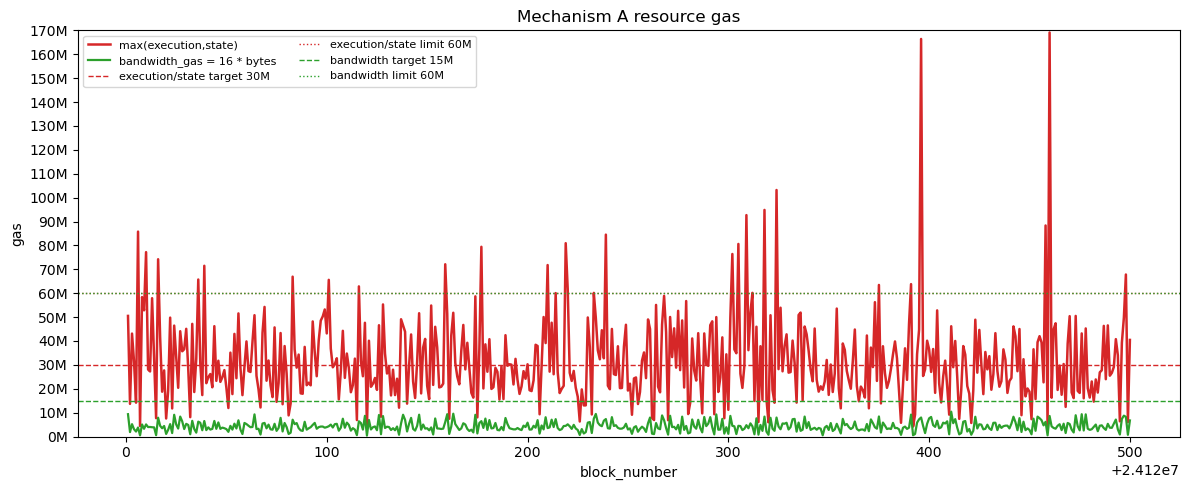

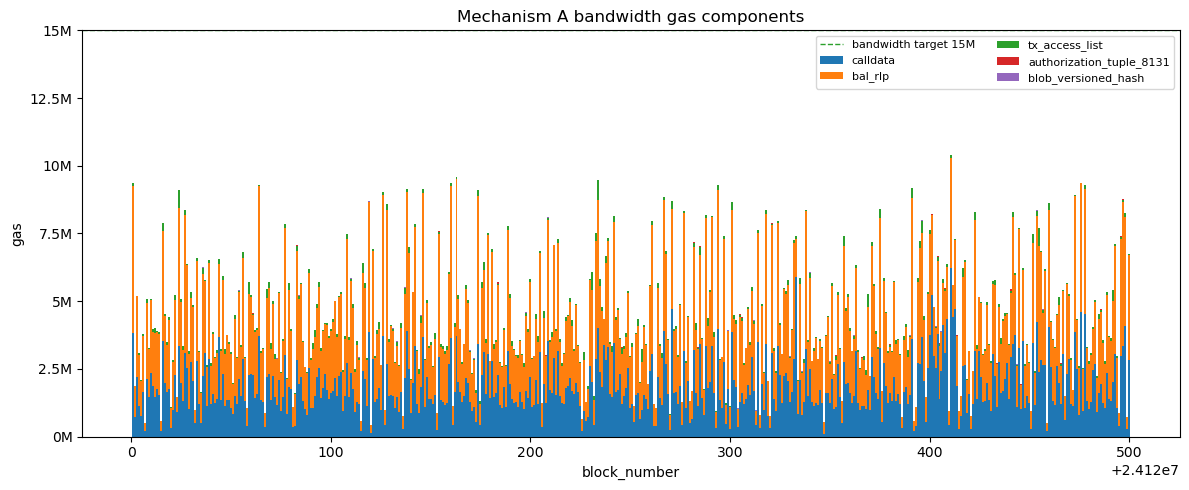

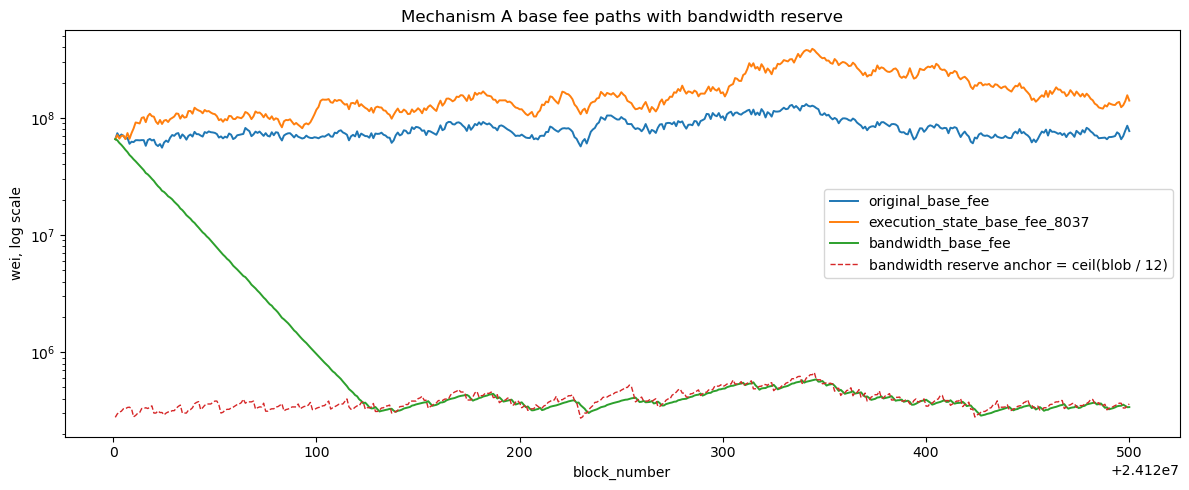

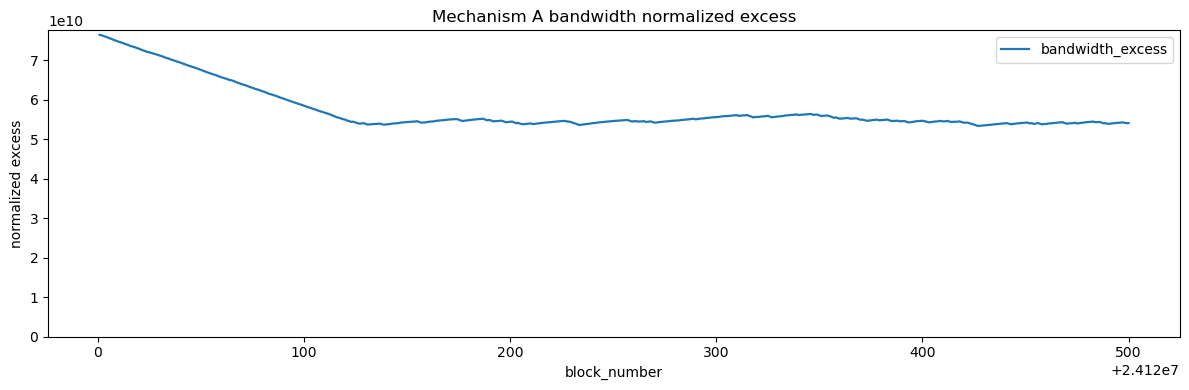

(PosixPath('/Users/william/PycharmProjects/eip-7999-research/plots/mechanism_A_resource_gas_24120001_24120500.png'),
 PosixPath('/Users/william/PycharmProjects/eip-7999-research/plots/mechanism_A_bandwidth_components_24120001_24120500.png'),
 PosixPath('/Users/william/PycharmProjects/eip-7999-research/plots/mechanism_A_base_fees_24120001_24120500.png'),
 PosixPath('/Users/william/PycharmProjects/eip-7999-research/plots/mechanism_A_bandwidth_excess_24120001_24120500.png'))

In [7]:
def set_million_axis(ax, series_names, reference_values=()):
    ymax = max([replay[name].max() for name in series_names] + list(reference_values))
    upper = int(((ymax + 10_000_000 - 1) // 10_000_000) * 10_000_000)
    ticks = list(range(0, upper + 1, 10_000_000))
    if 30_000_000 not in ticks and upper >= 30_000_000:
        ticks.append(30_000_000)
        ticks = sorted(ticks)
    ax.set_ylim(bottom=0, top=upper)
    ax.set_yticks(ticks)
    ax.set_yticklabels([f"{tick // 1_000_000}M" for tick in ticks])

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(
    replay["block_number"],
    replay["execution_state_gas_used"],
    label="max(execution,state)",
    linewidth=1.8,
    color="tab:red",
)
ax.plot(
    replay["block_number"],
    replay["bandwidth_gas_used"],
    label="bandwidth_gas = 16 * bytes",
    linewidth=1.6,
    color="tab:green",
)
ax.axhline(EXECUTION_STATE_GAS_TARGET, color="tab:red", linestyle="--", linewidth=1, label="execution/state target 30M")
ax.axhline(EXECUTION_STATE_GAS_LIMIT, color="tab:red", linestyle=":", linewidth=1, label="execution/state limit 60M")
ax.axhline(BANDWIDTH_GAS_TARGET, color="tab:green", linestyle="--", linewidth=1, label="bandwidth target 15M")
ax.axhline(BANDWIDTH_GAS_LIMIT, color="tab:green", linestyle=":", linewidth=1, label="bandwidth limit 60M")
set_million_axis(ax, ["execution_state_gas_used", "bandwidth_gas_used"], [EXECUTION_STATE_GAS_LIMIT, BANDWIDTH_GAS_LIMIT])
ax.set_title("Mechanism A resource gas")
ax.set_xlabel("block_number")
ax.set_ylabel("gas")
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()
fig.savefig(OUT_RESOURCE_GAS_PLOT, dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
bar_bottom = pd.Series(0, index=replay.index, dtype="float64")
for component, _bytes_col, gas_col in component_specs:
    ax.bar(
        replay["block_number"],
        replay[gas_col],
        bottom=bar_bottom,
        label=component,
        width=1.0,
        linewidth=0,
    )
    bar_bottom = bar_bottom + replay[gas_col].astype("float64")
ax.axhline(BANDWIDTH_GAS_TARGET, color="tab:green", linestyle="--", linewidth=1, label="bandwidth target 15M")
ax.set_ylim(bottom=0, top=15_000_000)
ax.set_yticks([0, 2_500_000, 5_000_000, 7_500_000, 10_000_000, 12_500_000, 15_000_000])
ax.set_yticklabels(["0M", "2.5M", "5M", "7.5M", "10M", "12.5M", "15M"])
ax.set_title("Mechanism A bandwidth gas components")
ax.set_xlabel("block_number")
ax.set_ylabel("gas")
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()
fig.savefig(OUT_BANDWIDTH_COMPONENTS_PLOT, dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(replay["block_number"], replay["original_base_fee"], label="original_base_fee", linewidth=1.4)
ax.plot(replay["block_number"], replay["execution_state_base_fee"], label="execution_state_base_fee_8037", linewidth=1.4)
ax.plot(replay["block_number"], replay["bandwidth_base_fee"], label="bandwidth_base_fee", linewidth=1.4)
ax.plot(
    replay["block_number"],
    replay["bandwidth_reserve_anchor_base_fee"],
    label="bandwidth reserve anchor = ceil(blob / 12)",
    linewidth=1.0,
    linestyle="--",
)
ax.set_title("Mechanism A base fee paths with bandwidth reserve")
ax.set_xlabel("block_number")
ax.set_ylabel("wei, log scale")
ax.set_yscale("log")
ax.legend()
fig.tight_layout()
fig.savefig(OUT_BASE_FEE_PLOT, dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(replay["block_number"], replay["bandwidth_excess"], label="bandwidth_excess", linewidth=1.6)
ax.set_title("Mechanism A bandwidth normalized excess")
ax.set_xlabel("block_number")
ax.set_ylabel("normalized excess")
ax.set_ylim(bottom=0)
ax.legend()
fig.tight_layout()
fig.savefig(OUT_EXCESS_PLOT, dpi=180)
plt.show()

OUT_RESOURCE_GAS_PLOT, OUT_BANDWIDTH_COMPONENTS_PLOT, OUT_BASE_FEE_PLOT, OUT_EXCESS_PLOT

## Interpretation

This notebook intentionally does **not** ask whether state would have its own
75M target. That is a later full EIP-7999 state-resource mechanism. Here state
is still EIP-8037: it can become the bottleneck through `max(execution, state)`,
but it does not have a separate fee market.

The key comparison against the 0.7 baseline is that current calldata gas is
removed from the execution/state dimension and all data bytes are priced in the
new bandwidth dimension at `16 gas/byte`.

Bandwidth also uses the EIP-7999 blob-base-fee reserve anchor. The diagnostic
anchor threshold is `ceil(blob_base_fee_per_gas / 12)`, but the base fee is not
hard-clamped to that value. The reserve affects the excess-gas update path, so
the bandwidth base fee climbs gradually while the reserve condition is active.

The separated bandwidth dimension is warm-started at the first block's historical
aggregate base fee. Its initial normalized excess is derived from that base fee,
so the first update continues from the historical price level instead of
collapsing to `min_base_fee = 1`.
